In [20]:
# import sys
# import os

# sys.path.append(os.path.abspath(".."))

In [21]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import nibabel as nib
import pandas as pd
import seaborn as sns
import os
import ast

from constants_BHSD import *
from utils_BHSD import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
### Unlabel folder
---

In [22]:

unlabeled_path = os.path.join(DATASET_ROOT, UNLABEL_DIR)
rows = []

for folder in os.listdir(unlabeled_path):
    folder_path = os.path.join(unlabeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,anybleed,562,.nii.gz
1,nobleed,1418,.nii.gz


---
### Label folder
---

In [23]:

labeled_path = os.path.join(DATASET_ROOT, LABEL_DIR)
rows = []

for folder in os.listdir(labeled_path):
    folder_path = os.path.join(labeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,ground truths,192,.nii.gz
1,images,192,.nii.gz


In [24]:
file_path = os.path.join(labeled_path, "ground truths")
file = os.path.join(file_path, "ID_0b10cbee_ID_f91d6a7cd2.nii.gz")
nii_img = nib.load(file)
data = nii_img.get_fdata()
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512  32   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.488281   0.488281   5.2284584  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 0.9890158176422119
quatern_d       : 0.1478094905614853
qoffset_x       : 134.3000030517

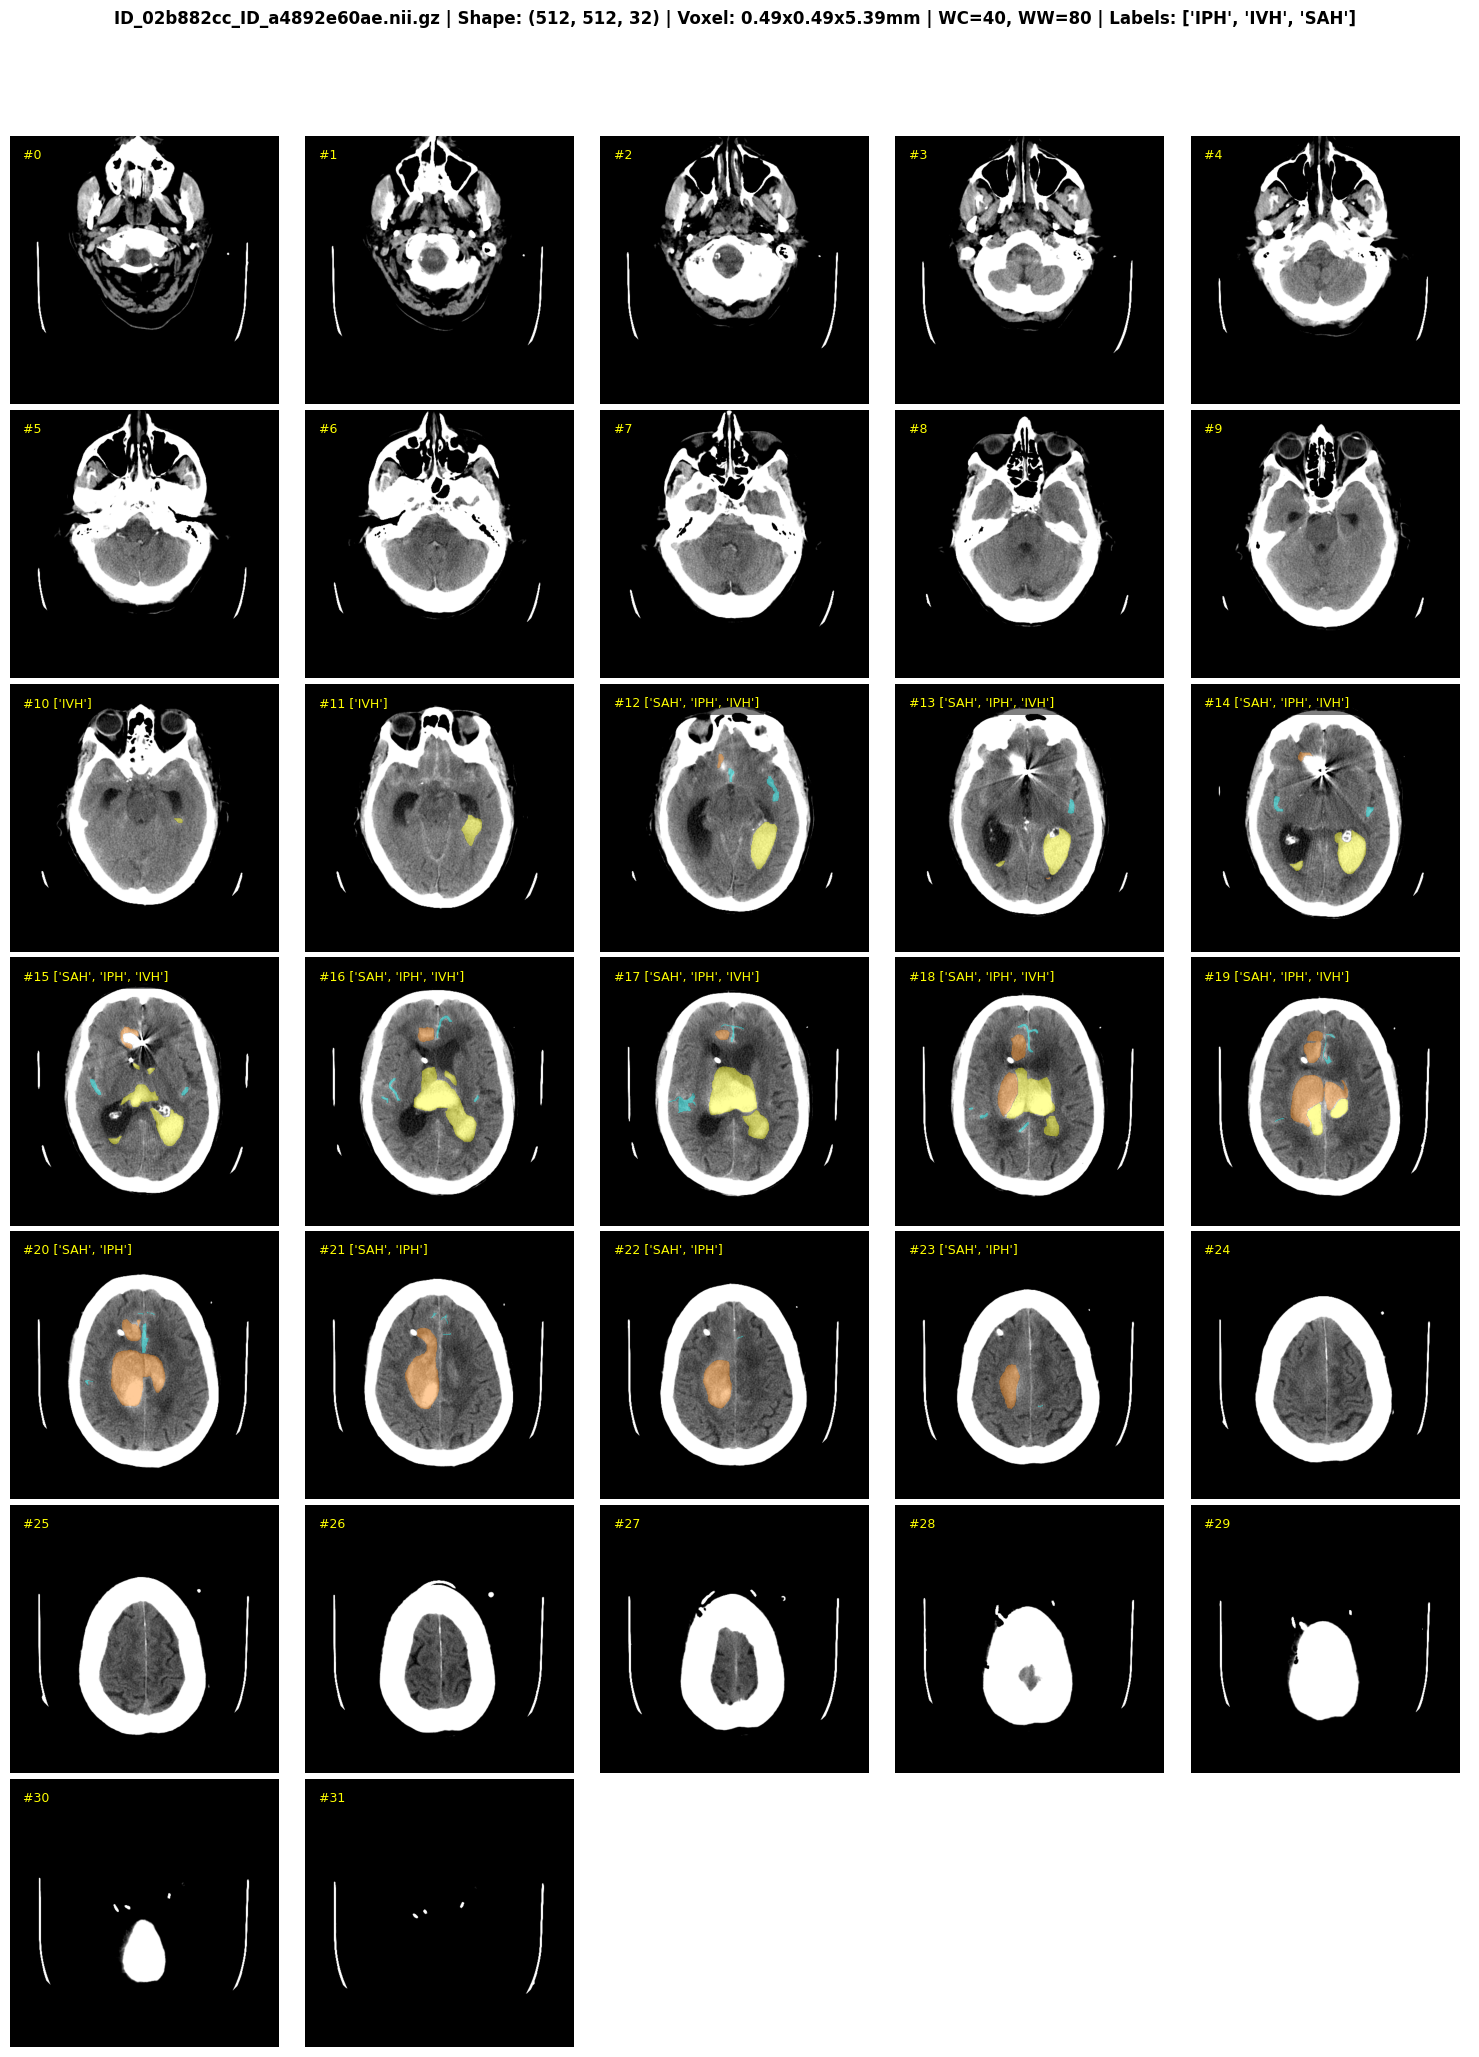

In [25]:
show_all_slices(
        "ID_02b882cc_ID_a4892e60ae.nii.gz",
        window=(40, 80),
        overlay=True
    )

In [26]:
df = pd.read_csv("header/BHSD_headers.csv")
df.nunique()

filename          192
aux_file            1
bitpix              1
cal_max             1
cal_min             1
data_type           1
datatype            1
db_name             1
descrip             1
dim                19
dim_info            1
extents             1
glmax               1
glmin               1
intent_code         1
intent_name         1
intent_p1           1
intent_p2           1
intent_p3           1
magic               1
pixdim            119
qform_code          1
qoffset_x          50
qoffset_y         158
qoffset_z         181
quatern_b           1
quatern_c          49
quatern_d          62
regular             1
scl_inter           0
scl_slope           0
session_error       1
sform_code          2
sizeof_hdr          1
slice_code          1
slice_duration      1
slice_end           1
slice_start         1
srow_x              2
srow_y              2
srow_z              2
toffset             1
vox_offset          1
xyzt_units          1
dtype: int64

In [27]:
drop_cols =['aux_file','glmax','glmin','sizeof_hdr', 'data_type','db_name', 'extents', 'session_error', 'regular', 'dim_info', 'intent_p1', 'intent_p2', 'intent_p3', 'intent_code', 'datatype', 'bitpix', 'slice_start', 'vox_offset', 'scl_slope', 'scl_inter', 'slice_end', 'slice_code', 'xyzt_units', 'cal_max', 'cal_min', 'slice_duration', 'toffset', 'descrip', 'qform_code', 'intent_name', 'magic']
df_drop = df.drop(columns=drop_cols)
df_drop.nunique()

filename      192
dim            19
pixdim        119
qoffset_x      50
qoffset_y     158
qoffset_z     181
quatern_b       1
quatern_c      49
quatern_d      62
sform_code      2
srow_x          2
srow_y          2
srow_z          2
dtype: int64

Text(0.5, 1.0, 'Distribution of Slices per Scan')

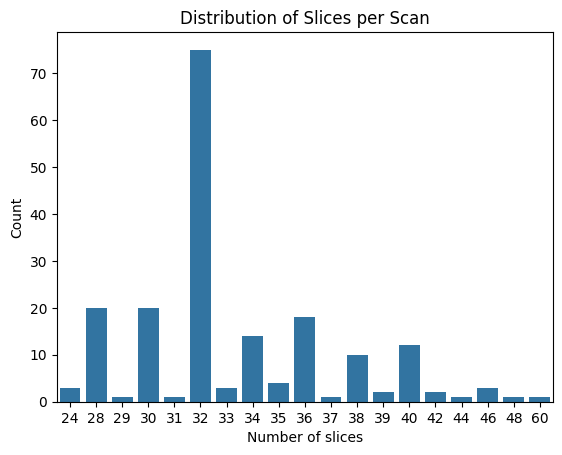

In [28]:
num_slices = df_drop['dim'].apply(ast.literal_eval).apply(lambda x: x[3]).value_counts().sort_index()

plt.figure()
sns.barplot(
    x=num_slices.index,
    y=num_slices.values
)

plt.xlabel("Number of slices")
plt.ylabel("Count")
plt.title("Distribution of Slices per Scan")